In [1]:
#Importing all the neccessary libraries

import sqlite3
import pandas as pd
import numpy as np
import nltk
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfTransformer, TfidfVectorizer, CountVectorizer
import sklearn.metrics as metrics
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
from nltk.stem.porter import PorterStemmer
import string
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
#from gensim.models import Word2Vec, KeyedVectors
import pickle
import warnings
warnings.filterwarnings("ignore")
from sklearn import datasets, neighbors
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from collections import Counter
from matplotlib.colors import ListedColormap
#import scikitplot.metrics as sciplot
from sklearn.metrics import accuracy_score
import math
import nltk
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...


True

In [2]:
filtered_data = pd.read_csv(r"C:\Users\DELL\Desktop\course_prac\NLP\Sentiment_Analysis Project\Reviews.csv")

In [3]:
filtered_data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
filtered_data.shape

(568454, 10)

In [5]:
filtered_data = filtered_data.sample(frac = 0.1,random_state=1)

score ranges from 1 to 5

below 3 -- negative review
above 3 -- positive review
equal to 3 -- neutral review

What if i don't have scores in my dataset?
Based on text data: whether the text data is positive, negative or neutral
Key words from the text data:
How to identify positive, negative and neutral words from the text data?
positive words: good, excellent, nice, amazing, fantastic, love, great, satisfied, happy, wonderful -- in one dictionary
Negative words: bad, poor, terrible, awful, hate, worst, disappointed, unsatisfied, unhappy -- in another dictionary

There may be a chnance that some words may be present in both the dictionaries:
How to deal with this: we will give more priority to negative words than positive words

What is naother way to identify positive, negative and neutral words from the text data?
We can use some pre defined libraries in python:nltk -- natural language toolkit    

Input text data --- I can build any clustering algorithm(three clusters) to identify positive, negative and neutral words from the text data

I am very bad satsfied with the product -- he will give rating as 4    

Sarcasm -- he will give rating as 4 but the review is negative

example for sarcasm: The product is good but the service is bad    -- TATA cars --- 

With in the tool we need to identify the positive, negative and neutral , sarcasm words from the text data

In [6]:
filtered_data.shape

(56845, 10)

In [7]:
filtered_data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
288312,288313,B000ENUC3S,AN66F3Q4QNU43,Donna Speaker,0,0,5,1340496000,Cherry Pie Larabar,I love the Cherry Pie Lara bar. Best and tast...
431726,431727,B002TMV3CG,A3G007LQX6KGOD,SevereWX,0,0,5,1287878400,Melitta Coffee,Melitta Cafe COllection Blanc et Noir coffee h...
110311,110312,B004867T24,A11LNY2OLQSUSV,M. Castillo,0,0,5,1331769600,great treat,my girls absolutely loved this tuna. they were...
91855,91856,B004U7KPY0,A1QCYVHWO5934U,"PistolaMia ""PistolaMia""",0,0,5,1332806400,Daily Calming,The vendor is fast and dependable. The tea is ...
338855,338856,B000FD78R0,A30U2QQN2FFHE9,J. Amicucci,2,3,5,1271376000,Best Canned Artichokes Out There!,UPDATE - 8/9/2010<br />A lot can happen in jus...


In [8]:
#Give reviews with Score > 3 a 'Positive' tag, and reviews with a score < 3 a 'Negative' tag.
filtered_data['SentimentPolarity'] = filtered_data['Score'].apply(lambda x : 'Positive' if x > 3 else ('Neutral'if x == 3 else 'Negative'))

In [9]:
filtered_data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,SentimentPolarity
288312,288313,B000ENUC3S,AN66F3Q4QNU43,Donna Speaker,0,0,5,1340496000,Cherry Pie Larabar,I love the Cherry Pie Lara bar. Best and tast...,Positive
431726,431727,B002TMV3CG,A3G007LQX6KGOD,SevereWX,0,0,5,1287878400,Melitta Coffee,Melitta Cafe COllection Blanc et Noir coffee h...,Positive
110311,110312,B004867T24,A11LNY2OLQSUSV,M. Castillo,0,0,5,1331769600,great treat,my girls absolutely loved this tuna. they were...,Positive
91855,91856,B004U7KPY0,A1QCYVHWO5934U,"PistolaMia ""PistolaMia""",0,0,5,1332806400,Daily Calming,The vendor is fast and dependable. The tea is ...,Positive
338855,338856,B000FD78R0,A30U2QQN2FFHE9,J. Amicucci,2,3,5,1271376000,Best Canned Artichokes Out There!,UPDATE - 8/9/2010<br />A lot can happen in jus...,Positive


In [10]:
filtered_data['SentimentPolarity'].value_counts()

SentimentPolarity
Positive    44391
Negative     8163
Neutral      4291
Name: count, dtype: int64

In [11]:
filtered_data['Class_Labels'] = filtered_data['SentimentPolarity'].apply(lambda x : 2 if x == 'Positive' else (1 if x == 'Neutral' else 0))

In [12]:
filtered_data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,SentimentPolarity,Class_Labels
288312,288313,B000ENUC3S,AN66F3Q4QNU43,Donna Speaker,0,0,5,1340496000,Cherry Pie Larabar,I love the Cherry Pie Lara bar. Best and tast...,Positive,2
431726,431727,B002TMV3CG,A3G007LQX6KGOD,SevereWX,0,0,5,1287878400,Melitta Coffee,Melitta Cafe COllection Blanc et Noir coffee h...,Positive,2
110311,110312,B004867T24,A11LNY2OLQSUSV,M. Castillo,0,0,5,1331769600,great treat,my girls absolutely loved this tuna. they were...,Positive,2
91855,91856,B004U7KPY0,A1QCYVHWO5934U,"PistolaMia ""PistolaMia""",0,0,5,1332806400,Daily Calming,The vendor is fast and dependable. The tea is ...,Positive,2
338855,338856,B000FD78R0,A30U2QQN2FFHE9,J. Amicucci,2,3,5,1271376000,Best Canned Artichokes Out There!,UPDATE - 8/9/2010<br />A lot can happen in jus...,Positive,2


In [13]:
filtered_data['Class_Labels'].value_counts()

Class_Labels
2    44391
0     8163
1     4291
Name: count, dtype: int64

In [14]:
filtered_data.shape

(56845, 12)

In [16]:
print("The number of positive,negative and Neutral reviews before the removal of duplicate data.")
print(filtered_data["SentimentPolarity"].value_counts())

The number of positive,negative and Neutral reviews before the removal of duplicate data.
SentimentPolarity
Positive    44391
Negative     8163
Neutral      4291
Name: count, dtype: int64


In [17]:
#Removing duplicate entries based on past knowledge.
filtered_duplicates=filtered_data.drop_duplicates(subset={"UserId","ProfileName","Time","Text"}, keep='first', inplace=True)

In [18]:
print("The number of positive,negative and Neutral reviews after the removal of duplicate data.")
print(filtered_data["SentimentPolarity"].value_counts())

The number of positive,negative and Neutral reviews after the removal of duplicate data.
SentimentPolarity
Positive    40741
Negative     7518
Neutral      3932
Name: count, dtype: int64


In [19]:
#Removing the entries where HelpfulnessNumerator > HelpfulnessDenominator.
final_data=filtered_data[filtered_data.HelpfulnessNumerator <= filtered_data.HelpfulnessDenominator]

In [20]:
final_data["SentimentPolarity"].value_counts()

SentimentPolarity
Positive    40741
Negative     7518
Neutral      3932
Name: count, dtype: int64

#### In this code block :

1. I am creating a copy of the final_data dataset called 'sampled_dataset' by dropping the unwanted columns that we don't need for this problem.
2. Sorting the data according to time, such that the oldest reviews are displayed at the top and the latest reviews are displayed at the bottom.
3. Displaying information about the number of postive,negative and neutral reviews in the sampled dataset, using a Histogram.

In [21]:
#Dropping unwanted columns for now.
sampled_dataset=final_data.drop(labels=['Id','ProductId', 'UserId', 'Score', 'ProfileName','HelpfulnessNumerator', 'HelpfulnessDenominator','Summary'], axis=1)
print("The shape of the sampled dataset after dropping unwanted columns : ", sampled_dataset.shape)
sampled_dataset.head()

The shape of the sampled dataset after dropping unwanted columns :  (52191, 4)


,Time,Text,SentimentPolarity,Class_Labels
288312,1340496000,I love the Cherry Pie Lara bar. Best and tast...,Positive,2
431726,1287878400,Melitta Cafe COllection Blanc et Noir coffee h...,Positive,2
110311,1331769600,my girls absolutely loved this tuna. they were...,Positive,2
91855,1332806400,The vendor is fast and dependable. The tea is ...,Positive,2
338855,1271376000,UPDATE - 8/9/2010<br />A lot can happen in jus...,Positive,2


In [22]:
#Sorting data according to Time in ascending order => Time Based Splitting Step 1.
sampled_dataset=sampled_dataset.sort_values('Time', axis=0, ascending=False, inplace=False, kind='quicksort', na_position='last')

In [23]:
sampled_dataset = sampled_dataset.reset_index()

In [24]:
sampled_dataset.head()

,index,Time,Text,SentimentPolarity,Class_Labels
0,317935,1351209600,It is hard to find much of anything sugarfree ...,Positive,2
1,271217,1351209600,Shake the container and they come running. Eve...,Positive,2
2,381087,1351209600,If you like sponge candy- and have never tried...,Positive,2
3,180007,1351209600,"Every month, we give our three dogs (two Aussi...",Positive,2
4,118928,1351209600,All my dogs love them. Healthy treats. Not gre...,Positive,2


In [25]:
sampled_dataset=sampled_dataset.drop(labels=['index'], axis=1)

In [26]:
sampled_dataset.head()

,Time,Text,SentimentPolarity,Class_Labels
0,1351209600,It is hard to find much of anything sugarfree ...,Positive,2
1,1351209600,Shake the container and they come running. Eve...,Positive,2
2,1351209600,If you like sponge candy- and have never tried...,Positive,2
3,1351209600,"Every month, we give our three dogs (two Aussi...",Positive,2
4,1351209600,All my dogs love them. Healthy treats. Not gre...,Positive,2


<Axes: title={'center': 'Distribution Of Positive,Negative and Neutral reviews after De-Duplication.'}, xlabel='SentimentPolarity'>

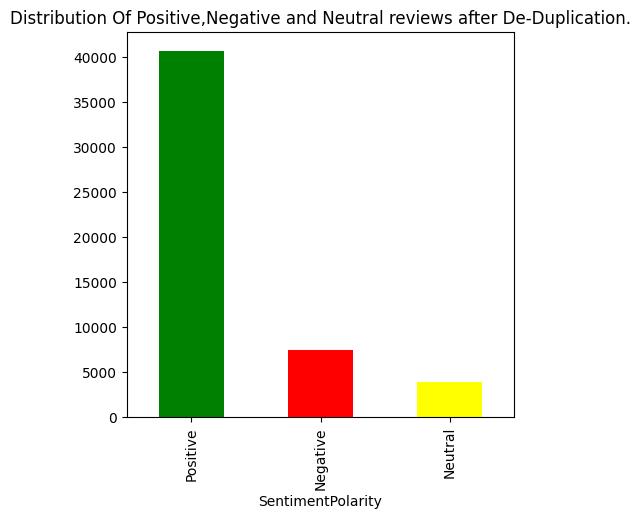

In [27]:
#Display distribution of Postive and Negative reviews in a bar graph
sampled_dataset["SentimentPolarity"].value_counts().plot(kind='bar',color=['green','red','yellow'],title='Distribution Of Positive,Negative and Neutral reviews after De-Duplication.',figsize=(5,5))

#### In this code block :

1. We define two functions which will remove the HTML tags and punctuations from each review.
2. At the end of this code block, each review will contain texts which will only contain alphabetical strings. 
3. We will apply techniques such as stemming and stopwords removal.
3. We will create two columns in the sampled dataset - 'CleanedText' and 'RemovedHTML'.
4. 'CleanedText' column will basically contain the data corpus after stemming the each reviews and removing stopwords from each review. We will use this for our Bag of Word model.
5. 'RemovedHTML' column will contain the data corpus from which only the HTML tags and punctuations are removed. We will use this column for our TF-IDF model, Average Word2Vec model and TF-IDF weighted average Word2Vec model.
6. Store the final table in a dataset called 'sampled_dataset' for future use.

In [29]:
import re

review = "i am satisfied with the product , and the service is good... @  ! 7 % $ and the delivery is on time <br /> <br /> overall i am happy with the product.product"

def RemoveHtml(sentence):
  pattern = re.compile('<.*?>')
  cleaned_text = re.sub(pattern,' ',sentence)
  return cleaned_text

In [31]:
cleaned_review=RemoveHtml(review)
print("The review after removing html tags : ",cleaned_review)

The review after removing html tags :  i am satisfied with the product , and the service is good... @  ! 7 % $ and the delivery is on time     overall i am happy with the product.product


In [32]:
#Function to keep only words containing letters A-Z and a-z. This will remove all punctuations, special characters etc.
def removePunctuations(sentence):
    cleaned_text  = re.sub('[^a-zA-Z]',' ',sentence)
    return cleaned_text

In [33]:
cleaned_review_only_text = removePunctuations(cleaned_review)
print("The review after removing  Punctuations : ",cleaned_review_only_text)

The review after removing  Punctuations :  i am satisfied with the product   and the service is good               and the delivery is on time     overall i am happy with the product product


In [34]:
# ineed to strip the text data and convert it into lower case
#Function to convert the entire sentence to lower case and strip the extra spaces.  
def stripLower(sentence):
    cleaned_text = sentence.lower().strip()
    cleaned_text = re.sub(' +', ' ', cleaned_text)
    return cleaned_text

In [35]:
final_cleaned_review = stripLower(cleaned_review_only_text)
print("The review after converting to lower case and stripping extra spaces : ",final_cleaned_review)

The review after converting to lower case and stripping extra spaces :  i am satisfied with the product and the service is good and the delivery is on time overall i am happy with the product product


In [36]:
final_cleaned_review

'i am satisfied with the product and the service is good and the delivery is on time overall i am happy with the product product'

In [37]:
def take_only_distinct_words(sentence):
  word_tokens = sentence.split()
  seen = set()
  cleaned_text = []
  for word in word_tokens:
    if word not in seen:
      cleaned_text.append(word)
      seen.add(word)
  cleaned_text = ' '.join(cleaned_text)
  return cleaned_text

cleaned_review_distinct_words = take_only_distinct_words(final_cleaned_review)
print("The review after taking only distinct words : ", cleaned_review_distinct_words)

The review after taking only distinct words :  i am satisfied with the product and service is good delivery on time overall happy


In [38]:
import nltk   #spacy
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [39]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [40]:
# my next step is to remove stop words from the text data

nltk.download('stopwords')
def removeStopWords(sentence):
  stop_words = set(stopwords.words('english'))
  word_tokens = sentence.split()
  cleaned_text = [word for word in word_tokens if not word in stop_words]
  cleaned_text = ' '.join(cleaned_text)
  return cleaned_text

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [41]:
rev_after_stopwords = removeStopWords(cleaned_review_distinct_words)

In [42]:
rev_test = "satisfy  satisfied  satisfied satisfaction satisfactory satisfyingly"
# next step is to use stemming or  lemmatisation on the text data:
from nltk.stem.porter import PorterStemmer
def stemming(sentence):
    porter_stemmer = PorterStemmer()
    word_tokens = sentence.split()
    cleaned_text = [porter_stemmer.stem(word) for word in word_tokens]
    cleaned_text = ' '.join(cleaned_text)
    return cleaned_text

In [43]:
review_after_stemming = stemming(rev_test)
print("The review after stemming : ",review_after_stemming)

The review after stemming :  satisfi satisfi satisfi satisfact satisfactori satisfyingli


In [44]:
# create a function to use the stemming technique with snowball stemmer
def stemming_with_snowball(sentence):
    from nltk.stem.snowball import SnowballStemmer
    snowball_stemmer = SnowballStemmer(language='english')
    word_tokens = sentence.split()
    cleaned_text = [snowball_stemmer.stem(word) for word in word_tokens]
    cleaned_text = ' '.join(cleaned_text)
    return cleaned_text

In [45]:
review_after_snowball_stemming = stemming_with_snowball(rev_test)
print("The review after snowball stemmer : ",review_after_snowball_stemming)

The review after snowball stemmer :  satisfi satisfi satisfi satisfact satisfactori satisfi


Stemming Vs Lemmatisation Explanation:
Stemming and lemmatization are both techniques used in natural language processing (NLP) to reduce words to their base or root form, but they do so in different ways and with different levels of accuracy.
Stemming:
Stemming is a crude heuristic process that chops off the ends of words in the hope of achieving the correct base form of the word. It often involves removing common prefixes or suffixes. Stemming algorithms, such as the Porter Stemmer or Snowball Stemmer, use simple rules to perform this task.
Lemmatisation:
Lemmatisation, on the other hand, is a more sophisticated process that considers the context and the morphological analysis of words. It involves using a vocabulary and morphological analysis of words to return the base or dictionary form of a word, known as the lemma. Lemmatisation takes into account the part of speech and the meaning of the word, which often results in more accurate base forms. For example, the lemma of "better" is "good," and the lemma of "running" is "run."
Lemmatisation typically requires more computational resources and is slower than stemming due to its complexity and reliance on linguistic knowledge.


Stemming is faster and more efficient, while lemmatization is more accurate and context-aware. The choice between the two depends on the specific requirements of the NLP task at hand.